# Task 4

## Task: Banknote Authentication Classification

In this task, you will work with the dataset provided in the file **`data_banknote_authentication.csv`**

Your objective is to build and evaluate classification models to predict the authenticity of banknotes.

You should:

- Load and explore the dataset.
- Build two classification models:
  - **Decision Tree**
  - **Random Forest**
- Use **GridSearchCV** to optimize the hyperparameters of each model.
- Evaluate the performance of both models using:
  - **Confusion Matrix**
  - **Classification Report**

Finally, **compare the performance of the two models** and discuss which model performs better for this dataset.

# Import and explore 

In [11]:
# ===============================
# 1. Import libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ===============================
# 2. Load the dataset
# ===============================
df = pd.read_csv("data_banknote_authentication.csv")

# Show first 5 rows
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [2]:
# ===============================
# 3. Basic dataset inspection
# ===============================
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

Shape of dataset: (1372, 5)

Column names:
Index(['Variance_Wavelet', 'Skewness_Wavelet', 'Curtosis_Wavelet',
       'Image_Entropy', 'Class'],
      dtype='object')

Data types:
Variance_Wavelet    float64
Skewness_Wavelet    float64
Curtosis_Wavelet    float64
Image_Entropy       float64
Class                 int64
dtype: object


In [3]:
# ===============================
# 4. Check missing values
# ===============================
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Variance_Wavelet    0
Skewness_Wavelet    0
Curtosis_Wavelet    0
Image_Entropy       0
Class               0
dtype: int64


In [4]:
# ===============================
# 5. Statistical summary
# ===============================
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [5]:
# ===============================
# 6. Check duplicates
# ===============================
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 24


In [6]:
# ===============================
# 7. Class distribution
# ===============================
print("Class distribution:")
print(df["Class"].value_counts())

print("\nClass proportions:")
print(df["Class"].value_counts(normalize=True))


Class distribution:
Class
0    762
1    610
Name: count, dtype: int64

Class proportions:
Class
0    0.555394
1    0.444606
Name: proportion, dtype: float64


In [7]:
# ===============================
# 8. Correlation matrix
# ===============================
corr_matrix = df.corr()
print(corr_matrix)

                  Variance_Wavelet  Skewness_Wavelet  Curtosis_Wavelet  \
Variance_Wavelet          1.000000          0.264026         -0.380850   
Skewness_Wavelet          0.264026          1.000000         -0.786895   
Curtosis_Wavelet         -0.380850         -0.786895          1.000000   
Image_Entropy             0.276817         -0.526321          0.318841   
Class                    -0.724843         -0.444688          0.155883   

                  Image_Entropy     Class  
Variance_Wavelet       0.276817 -0.724843  
Skewness_Wavelet      -0.526321 -0.444688  
Curtosis_Wavelet       0.318841  0.155883  
Image_Entropy          1.000000 -0.023424  
Class                 -0.023424  1.000000  


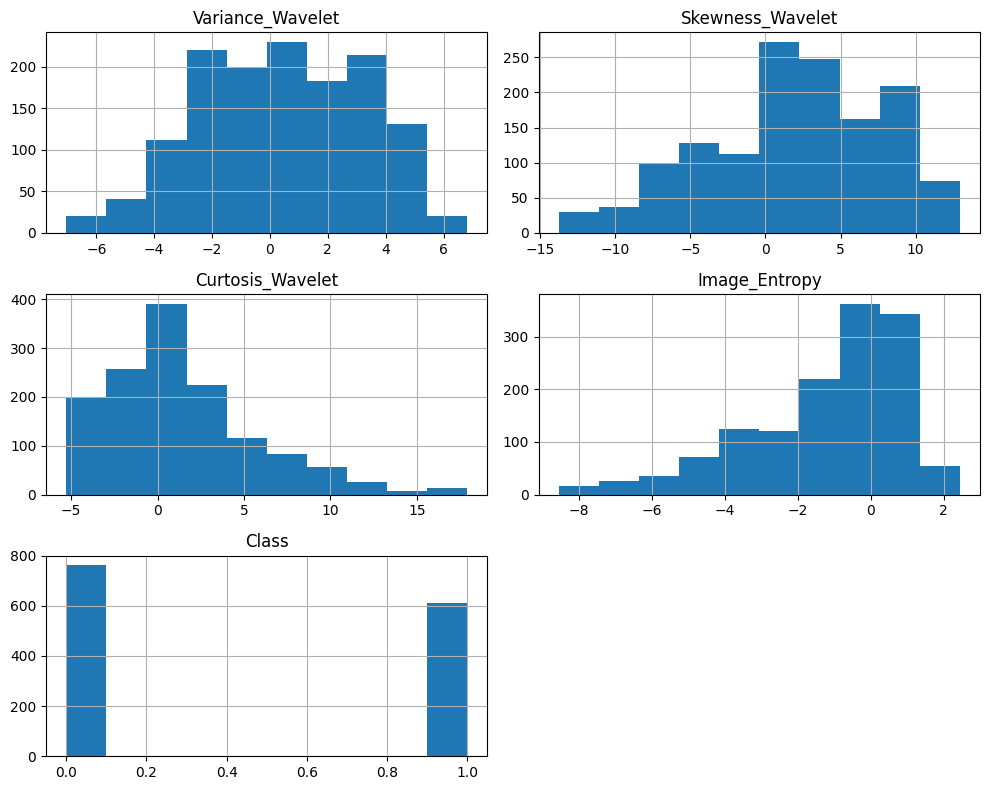

In [8]:
# ===============================
# 9. Histograms for all features
# ===============================
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

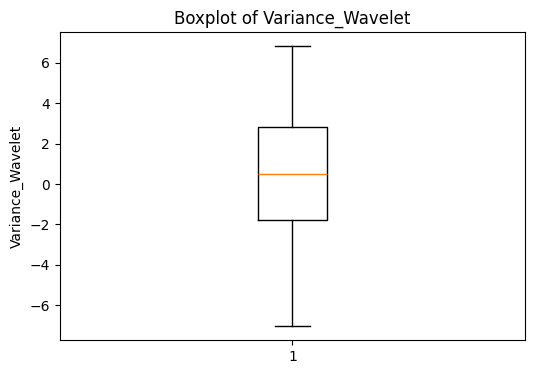

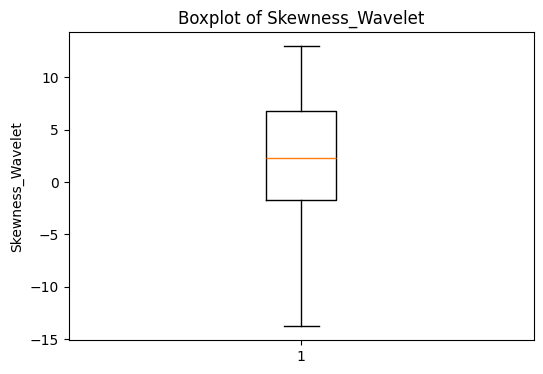

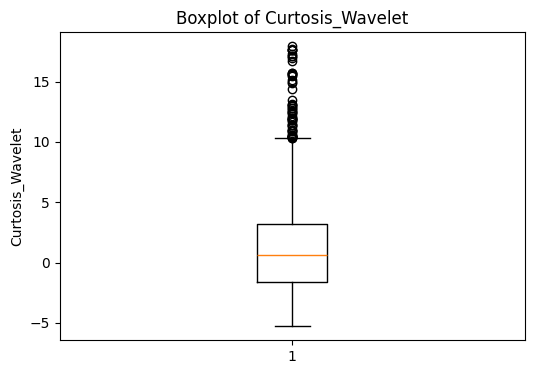

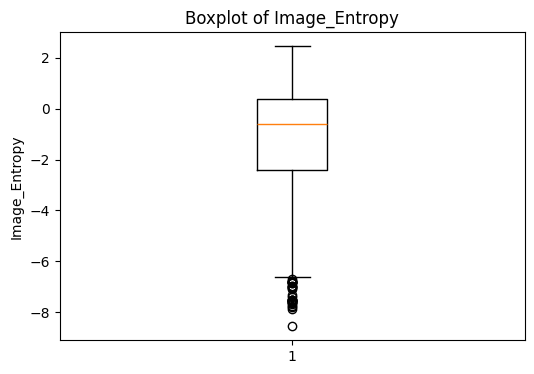

In [9]:
# ===============================
# 10. Boxplots to inspect spread/outliers
# ===============================
for col in df.columns[:-1]:   # exclude target column
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

# Build the decision tree


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1097, 4)
X_test shape: (275, 4)
y_train shape: (1097,)
y_test shape: (275,)


In [14]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
y_pred_dt = dt_model.predict(X_test)

In [16]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9927272727272727

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       153
           1       0.98      1.00      0.99       122

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275

Decision Tree Confusion Matrix:
[[151   2]
 [  0 122]]


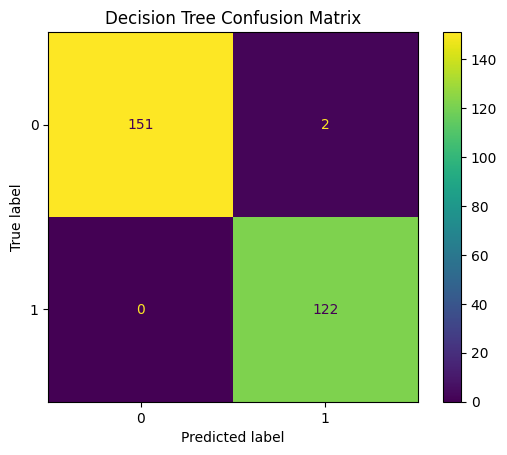

In [17]:
ConfusionMatrixDisplay.from_estimator(dt_model, X_test, y_test)
plt.title("Decision Tree Confusion Matrix")
plt.show()

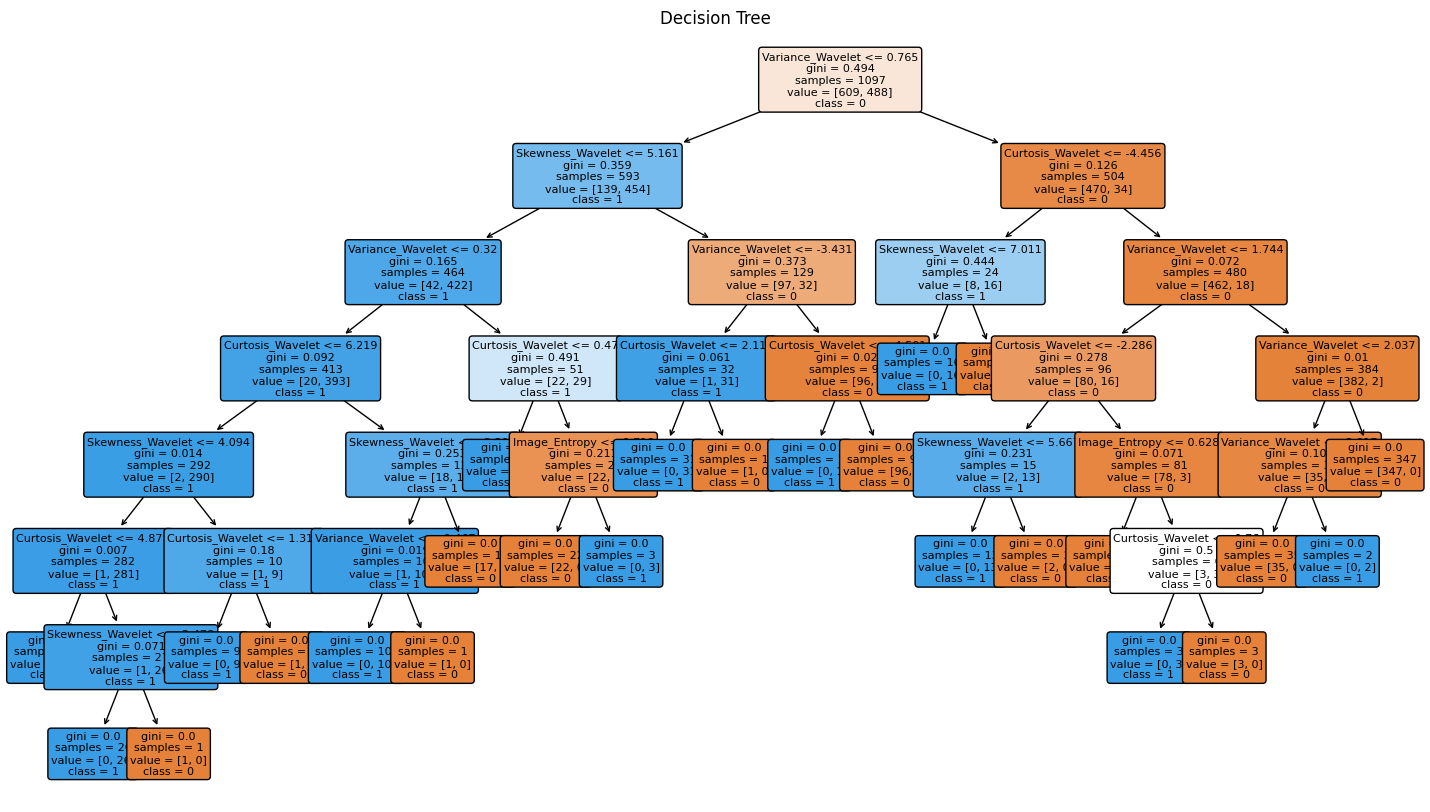

In [18]:
plt.figure(figsize=(18, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree")
plt.show()

# Build the random forest

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
y_pred_rf = rf_model.predict(X_test)

In [21]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_accuracy)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9963636363636363

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       153
           1       0.99      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

Random Forest Confusion Matrix:
[[152   1]
 [  0 122]]


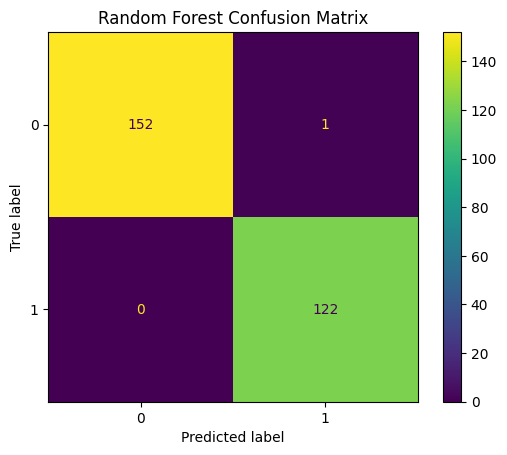

In [22]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [23]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Decision Tree,0.992727
1,Random Forest,0.996364


The Decision Tree and Random Forest classifiers both achieved excellent performance on the banknote authentication dataset. The Decision Tree obtained an accuracy of 99.27% and made only two misclassifications, while the Random Forest achieved 99.64% accuracy with only one misclassification. In both models, recall for class 1 was perfect, indicating that all class 1 samples were correctly identified. The Random Forest showed slightly better precision and overall balance, making it the best-performing model. However, the difference between the two models was small, which suggests that the dataset is highly separable and can already be modeled very effectively by a single Decision Tree.

# Cross-validation

In [25]:
from sklearn.model_selection import cross_val_score

dt_scores = cross_val_score(DecisionTreeClassifier(random_state=42), X, y, cv=5, scoring='accuracy')
rf_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), X, y, cv=5, scoring='accuracy')

print("Decision Tree CV Scores:", dt_scores)
print("Decision Tree Mean CV Accuracy:", dt_scores.mean())

print("Random Forest CV Scores:", rf_scores)
print("Random Forest Mean CV Accuracy:", rf_scores.mean())

Decision Tree CV Scores: [0.98909091 0.97090909 0.97445255 0.98540146 0.98540146]
Decision Tree Mean CV Accuracy: 0.981051094890511
Random Forest CV Scores: [0.99272727 0.99636364 0.99635036 0.99635036 0.99635036]
Random Forest Mean CV Accuracy: 0.9956284007962839


Cross-validation confirmed that the Random Forest classifier outperformed the Decision Tree not only in test accuracy but also in stability across folds. The Decision Tree achieved a mean cross-validation accuracy of 98.11%, while the Random Forest achieved 99.56%. In addition, the Random Forest showed less variation across folds, indicating stronger generalization and more reliable performance. Therefore, although both models performed very well, Random Forest is the preferred model for this dataset.